<a href="https://colab.research.google.com/github/SampMark/SampMark/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Modelo de Regressão Linear Múltipla**

A regressão linear múltipla é usada para prever uma variável dependente contínua a partir de múltiplas variáveis independentes.

Neste caso, além da variável ENGINESIZE, foram consideradas para efeito de análise o FUELCONSUMPTION_COMB e CYLINDERS, enquanto a variável dependente é CO2EMISSIONS.

Cada variável independente contribui para prever o valor da variável dependente com um peso específico, representado pelos coeficientes 𝜃1,𝜃2,…,𝜃𝑛, no modelo.

Todavia, a adição de múltiplas variáveis preditoras, embora possa melhorar a precisão do modelo, também pode distorcê-lo, pode introduzir a problemas como o da multicolinearidade (isto é, quando as variáveis preditoras estão altamente correlacionadas). Isto pode distorcer os coeficientes e produzir *overfiting* (sobreajuste ou "ajustamento excessivo"), o que pode reduzir a possibilidade de generalização e até a interpretabilidade do modelo.

**Instalando bibliotecas Python**

---



In [16]:
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install seaborn
%matplotlib inline

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

**Importação e Análise Exploratória dos Dados**

---



In [21]:
# importando e explorando os dados
df = pd.read_csv("https://raw.githubusercontent.com/SampMark/files/refs/heads/main/FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [22]:
# Selecionando as variáveis independentes de interesse
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244
5,3.5,6,11.9,7.7,10.0,230
6,3.5,6,11.8,8.1,10.1,232
7,3.7,6,12.8,9.0,11.1,255
8,3.7,6,13.4,9.5,11.6,267


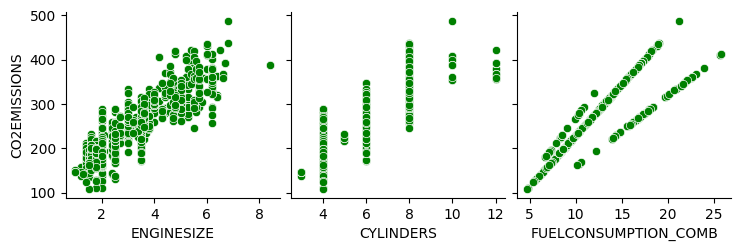

In [28]:
# Plota gráficos de dispersão em pares para as variáveis selecionadas
sns.pairplot(df, x_vars=['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB'], y_vars='CO2EMISSIONS', kind='scatter', plot_kws={'color': 'green'})
plt.show()

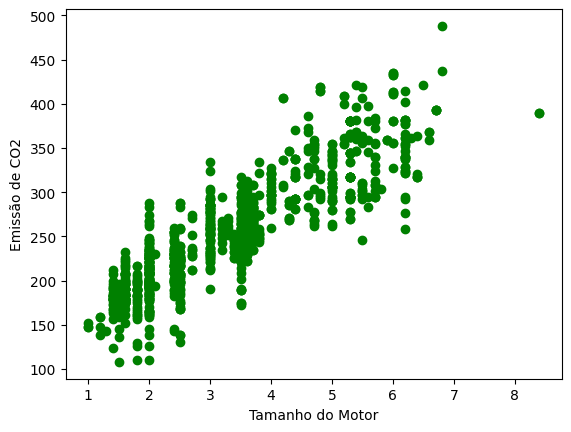

In [20]:
# Plota gráfico de correlação entre as variável depedente, Emissão de CO2, em relação a variável idependente, Tamanho do Motor
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='green')
plt.xlabel("Tamanho do Motor")
plt.ylabel("Emissão de CO2")
plt.show()

**Modelagem em Machine Learn**

---



In [10]:
# Separa os dados nos conjuntos de treinamento (0.8) e teste (0.2), utilizando a função np.random.rand() para mascarar, selecionar linhas aleatoriamente
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

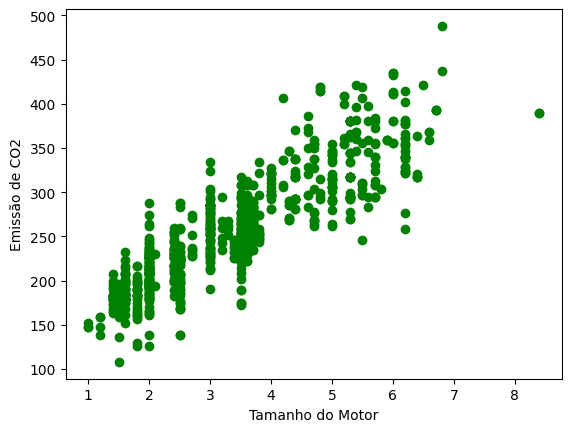

In [11]:
# Treina o modelo com base na distribuição dos dados
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='green')
plt.xlabel("Tamanho do Motor")
plt.ylabel("Emissão de CO2")
plt.show()

In [29]:
# Utilizando a biblioteca Scikit-learn para modelar os dados
from sklearn import linear_model
regr = linear_model.LinearRegression()
# Definição da variável preditora (X) e a variável alvo (y)
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
# Ajuste do modelo de regressão aos dados
regr.fit(train_x, train_y)
# Exibindo os coeficientes do modelo
print ('Coeficientes: ', regr.coef_)
print ('Intercepto: ',regr.intercept_)

Coeficientes:  [[38.86944497]]
Intercepto:  [126.72386637]


**Modelo de Regressão Linear Simples**

---



Text(0, 0.5, 'Emissão de CO2')

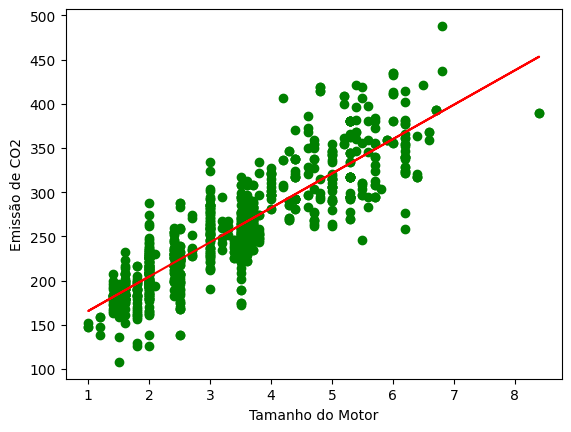

In [31]:
# Modelo de regressão linear simples, traçando a linha de ajuste (de tendência) dos dados
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='green')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Tamanho do Motor")
plt.ylabel("Emissão de CO2")

**Modelo de Regressão Linear Múltipla com 2 variáveis idependentes**

---



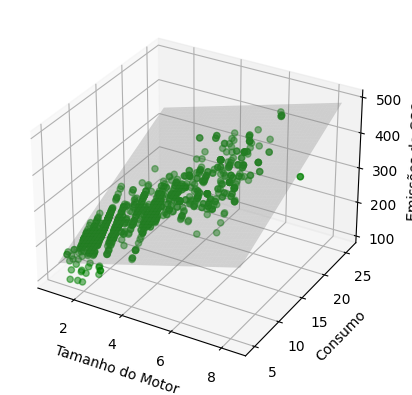

In [135]:
from mpl_toolkits.mplot3d import Axes3D

# Definição das variáveis preditoras (X) e a variável alvo (y)
x1 = df['ENGINESIZE']
x2 = df['FUELCONSUMPTION_COMB']
X = df[['ENGINESIZE', 'FUELCONSUMPTION_COMB']]
Y = df['CO2EMISSIONS']

# Cria a malha para o gráfico de superfície
x1_surf, x2_surf = np.meshgrid(np.linspace(x1.min(), x1.max(), 100), np.linspace(x2.min(), x2.max(), 100))
X_surf = np.column_stack((x1_surf.ravel(), x2_surf.ravel()))
Y_pred_surf = regr.predict(X_surf).reshape(x1_surf.shape)

# Gera o gráfico de superfície 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, Y, c='green', marker='o', alpha=0.5)
ax.plot_surface(x1_surf, x2_surf, Y_pred_surf, color='grey', alpha=0.3)
ax.set_xlabel('Tamanho do Motor')
ax.set_ylabel('Consumo')
ax.set_zlabel('Emissões de CO2')
plt.show()

In [136]:
# Estimação dos coeficientes do modelo de regressão linear múltipla para previsão da emissão de CO2, usando os preditores ENGINESIZE e FUELCONSUMPTION_COMB
from sklearn import linear_model
# Definição das variáveis preditoras (X) e a variável alvo (y)
# np.asarray() converte os dados em arrays NumPy para tornar eficiente os cálculos e train, um DataFrame Pandas contem os dados originais usados para treinar o modelo
x = np.asanyarray(train[['ENGINESIZE','FUELCONSUMPTION_COMB']])
y = np.asanyarray(train[['CO2EMISSIONS']])
regr = linear_model.LinearRegression()
# Ajuste do modelo de regressão aos dados
regr.fit (x, y)
# Exibindo os coeficientes e o intercepto do modelo
print ('Coeficientes: ', regr.coef_)
print ('Intercepto: ',regr.intercept_)

Coeficientes:  [[19.94591567  9.45830895]]
Intercepto:  [80.22493694]


**Regressão Linear Múltipla com 3 variáveis idependentes**

---



In [50]:
# Estimação dos coeficientes do modelo de regressão linear múltipla para previsão da emissão de CO2, usando os preditores FUELCONSUMPTION_COMB e CYLINDERS, além da ENGINESIZE
from sklearn import linear_model
regr = linear_model.LinearRegression()
# Definição das variáveis preditoras (X) e a variável alvo (y)
x = np.asanyarray(train[['ENGINESIZE','FUELCONSUMPTION_COMB','CYLINDERS']])
y = np.asanyarray(train[['CO2EMISSIONS']])
# Ajuste do modelo de regressão aos dados
regr.fit (x, y)
# Exibindo os coeficientes e o intercepto do modelo
print ('Coeficientes: ', regr.coef_)
print ('Intercepto: ',regr.intercept_)

Coeficientes:  [[11.40869283  9.32744095  7.42339233]]
Intercepto:  [67.30018986]


A biblioteca scikit-learn fornece a implementação direta do Método dos Mínimos Quadrados Ordinários (OLS), com o objeto LinearRegression. O método .fit(X, y) ajusta o modelo aos dados fornecidos, e o atributo .coef_ exibe os coeficientes das variáveis preditoras, enquanto .intercept_ retorna o intercepto do modelo.

O OLS escolhe os parâmetros de uma função linear de um conjunto de variáveis explicativas minimizando a soma dos quadrados das diferenças entre a variável dependente alvo e aquelas previstas pela função linear.

Em outras palavras, ele tenta minimizar a soma dos erros quadrados (SSE) ou o erro quadrático médio (MSE) entre a variável alvo (y) e nossa saída prevista (y^) em todas as amostras no conjunto de dados.

Assim, o OLS busca encontrar os melhores parâmetros a partir dos seguintes métodos:

*   Resolvendo os parâmetros do modelo analiticamente, usando equações de forma fechada; ou
*   usando um algoritmo de otimização (Gradiente Descendente, Gradiente Descendente Estocástico, Método de Newton, etc.).

In [51]:
y_hat= regr.predict(test[['ENGINESIZE','FUELCONSUMPTION_COMB','CYLINDERS']])
x = np.asanyarray(test[['ENGINESIZE','FUELCONSUMPTION_COMB','CYLINDERS']])
y = np.asanyarray(test[['CO2EMISSIONS']])
print("Erro Quadrático Médio (MSE) : %.2f"
      % np.mean((y_hat - y) ** 2))
#A função score() do scikit-learn calcula automaticamente a variância explicada do modelo (R2)
print('R2-score: %.2f' % regr.score(x, y))

Erro Quadrático Médio (MSE) : 548.02
R2-score: 0.87


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


Após ajustar o modelo e realizar as predições, o cálculo do Erro Quadrático Médio (MSE) e da variância explicada (R2-score) ajudam a avaliar a performance do modelo. O MSE mostra a magnitude média dos erros de previsão em termos quadráticos, enquanto a variância explicada indica quanta variabilidade o modelo conseguiu capturar em relação aos dados reais.

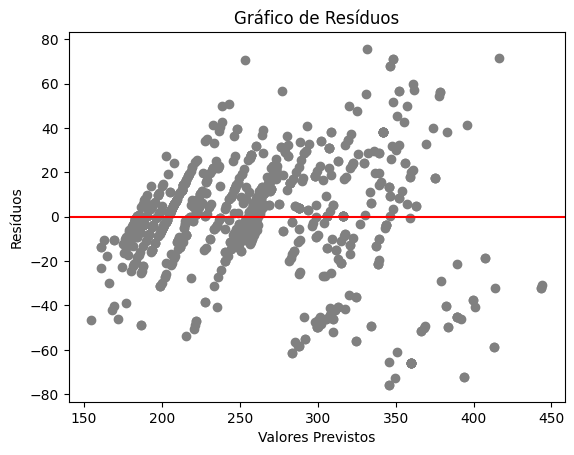

In [138]:
# Faça as previsões
y_pred = regr.predict(x)

# Calcule os resíduos
residuals = y - y_pred

# Crie o gráfico de resíduos
plt.scatter(y_pred, residuals, color='grey')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos')
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

**Interpretação do Gráfico de Resíduos**

Os resíduos são as diferenças entre os valores reais e os valores previstos pelo modelo. O ideal é que os resíduos sejam distribuídos de forma aleatória ao redor da linha vermelha (y=0), sem padrões evidentes. Isso indicaria que o modelo não tem vieses significativos e que a relação entre as variáveis independentes e a variável dependente foi bem capturada pelo modelo.

Mas se houver um padrão claro nos resíduos, como um formato de curva, tendência ou agrupamento, isso pode sugerir:

1.   **Heterocedasticidade**: Quando a variabilidade dos resíduos muda ao longo dos valores previstos, indicando que o modelo pode não estar capturando adequadamente a variância dos dados.
2.   **Falha na linearidade**: Se os resíduos formarem um padrão curvilíneo, isso pode indicar que a relação entre as variáveis preditoras e a variável alvo não é completamente linear e que um modelo mais complexo (por exemplo, regressão polinomial) pode ser necessário.
3. **Outliers**: Resíduos muito altos (acima ou abaixo de 0) podem indicar a presença de *outliers*, isto é, "pontos fora da curva" que o modelo não conseguiu prever adequadamente.

No gráfico acima, há alguma dispersão dos resíduos em torno da linha vermelha, com alguns grupos de pontos se destacando, podendo indicar que o modelo não está capturando bem certos padrões nos dados ou que há heterocedasticidade presente, onde a variabilidade dos resíduos muda para diferentes intervalos de valores previstos. Além disso, há alguns resíduos com valores muito altos, o que pode ser um indicativo de outliers nos dados.

In [15]:
# Teste com as variáveis FUELCONSUMPTION_CITY e FUELCONSUMPTION_HWY
# Prepare the features (X) and target variable (y)
regr = linear_model.LinearRegression()
x = np.asanyarray(train[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']])
y = np.asanyarray(train[['CO2EMISSIONS']])

# Criando e trainando o modelo de regressão linear
regr = linear_model.LinearRegression()
regr.fit(x, y)
print('Coeficientes: ', regr.coef_)

# Calculando as predições no conjunto de dados de teste
y_hat = regr.predict(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']])
x = np.asanyarray(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']])
y = np.asanyarray(test[['CO2EMISSIONS']])

# Validando o modelo
print("Erro Quadrático Médio (MSE): %.2f" % np.mean((y_hat - y) ** 2))
print('Variance Score: %.2f' % regr.score(x, y))

Coeficientes:  [[11.39532286  7.64212106  4.53756919  4.96242593]]
Erro Quadrático Médio (MSE): 555.57
Variance Score: 0.87


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
